<a href="https://colab.research.google.com/github/KiselevaStacy/python-ai--/blob/main/notebooks/week3_dogs_3d_combined.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🐕 Week 3: Обобщённый график — масса, рост и продолжительность жизни

## Цель: Визуализировать три параметра пород собак на одном графике

**Параметры:**
- X = масса (кг)
- Y = высота в холке (см)
- Цвет / размер / толщина = продолжительность жизни (лет)

**Задача:** Выбрать наиболее наглядный способ кодировки третьей переменной.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from scipy import stats

repo_path = "/content/python-ai--"
if not os.path.exists(repo_path):
    !git clone -q https://github.com/KiselevaStacy/python-ai--.git
if os.getcwd() != repo_path:
    %cd python-ai--

print("✅ Репозиторий готов\n")

df_dogs = pd.read_csv("data/dog_breeds.csv")
print(f"📊 Загружено строк в df_dogs: {len(df_dogs)}")

if "dogBreed" in df_dogs.columns:
    df_dogs = df_dogs.rename(columns={"dogBreed": "URL"})

technical_cols = ["heightQualifierLabel", "massQualifierLabel", "lifeExpectancyQualifierLabel",
                  "heightUnit", "massUnit", "lifeExpectancyUnit"]
cols_to_drop = [c for c in technical_cols if c in df_dogs.columns]
if cols_to_drop:
    df_dogs = df_dogs.drop(columns=cols_to_drop)

breed_col = None
for col in ["dogBreedLabel", "breedLabel", "Breed", "breed", "name", "label"]:
    if col in df_dogs.columns:
        breed_col = col
        break
if breed_col:
    df_dogs = df_dogs.rename(columns={breed_col: "dogBreed"})

for col in ["height", "mass", "lifeExpectancy"]:
    if col in df_dogs.columns:
        df_dogs[col] = pd.to_numeric(df_dogs[col], errors="coerce")

print("✅ df_dogs очищен\n")

# Группировка по породам
df_ranges = df_dogs.groupby('dogBreed').agg(
    mass_min=('mass', 'min'),
    mass_max=('mass', 'max'),
    height_min=('height', 'min'),
    height_max=('height', 'max'),
    lifeExpectancy=('lifeExpectancy', 'median')
).reset_index()

# Фильтруем породы с полными данными по всем трём параметрам
df_combined = df_ranges[
    df_ranges['mass_min'].notna() &
    df_ranges['mass_max'].notna() &
    df_ranges['height_min'].notna() &
    df_ranges['height_max'].notna() &
    df_ranges['lifeExpectancy'].notna()
].copy()

print(f"✅ Пород с полными данными по трём параметрам: {len(df_combined)}")

# Перевод названий на русский
BREED_TRANSLATIONS = {
    "Ariege Pointer":       "Арьежский пуантёр",
    "Cesky Fousek":         "Чешский фоусек",
    "Chippiparai":          "Чиппипарай",
    "Mudhol Hound":         "Мудхольская борзая",
    "Pembroke Welsh Corgi": "Вельш-корги пемброк",
}
df_combined["dogBreed_ru"] = df_combined["dogBreed"].replace(BREED_TRANSLATIONS)

print(df_combined[['dogBreed_ru', 'mass_min', 'mass_max', 'height_min', 'height_max', 'lifeExpectancy']].head(10))

/content/python-ai--
✅ Репозиторий готов

📊 Загружено строк в df_dogs: 2434
✅ df_dogs очищен

✅ Пород с полными данными по трём параметрам: 16
                       dogBreed_ru  mass_min  mass_max  height_min  \
38                  Чешский фоусек      22.0      34.0        58.0   
127            Вельш-корги пемброк       9.0      12.0        25.0   
218            Аляскинский маламут      34.0      38.0        58.5   
221  Американский водяной спаниель      11.5      20.5        38.0   
224         Американский фоксхаунд      30.0      34.0        53.0   
226           Анатолийская овчарка      40.0      65.0        71.0   
239               Афганская борзая      23.0      27.0        63.0   
240                    Аффенпинчер       4.0       6.0        25.0   
245                   Бассет-хаунд      32.0      32.0        33.0   
384               Немецкая овчарка      22.0      40.0        55.0   

     height_max  lifeExpectancy  
38         66.0            12.0  
127        30.0   

# 💬 Фидбек AI 1 (к подготовке данных)

**Результат:** Получено 16 пород с полными данными по массе, росту и продолжительности жизни.

**Требование преподавателя:** Построить обобщённый график, где третья переменная (продолжительность жизни) закодирована визуально.

**Варианты кодировки:**
1. Цвет заливки прямоугольника
2. Толщина рамки
3. Вложенные рамки (количество обводок)
4. Размер точки в центре
5. Насыщенность / прозрачность цвета

## 📊 Вариант A: Цвет заливки прямоугольника (рекомендованный)

**Логика:** Красный = меньше лет, зелёный = больше лет. Интуитивно понятно, не требует дополнительных пояснений.

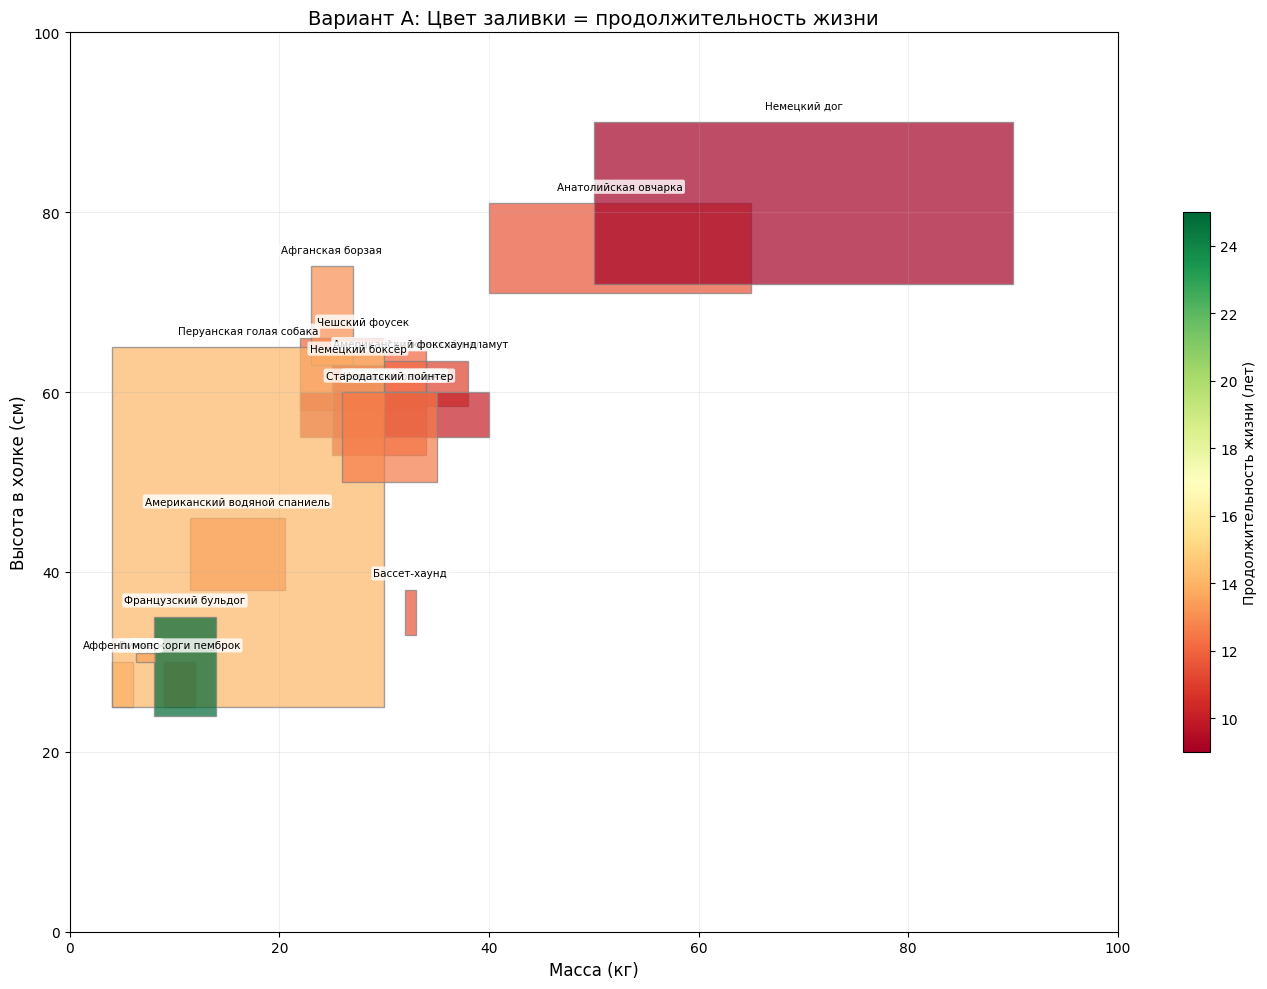

In [2]:
fig, ax = plt.subplots(figsize=(14, 10))

life_min = df_combined['lifeExpectancy'].min()
life_max = df_combined['lifeExpectancy'].max()
norm = mcolors.Normalize(vmin=life_min, vmax=life_max)
cmap = cm.RdYlGn

for _, row in df_combined.iterrows():
    mass_w = row['mass_max'] - row['mass_min']
    height_h = row['height_max'] - row['height_min']
    color = cmap(norm(row['lifeExpectancy']))

    rect = plt.Rectangle(
        (row['mass_min'], row['height_min']),
        max(mass_w, 1), max(height_h, 1),
        fill=True, facecolor=color, edgecolor='gray',
        alpha=0.7, linewidth=1
    )
    ax.add_patch(rect)

    # Подпись
    center_x = row['mass_min'] + max(mass_w, 1) / 2
    ax.annotate(row['dogBreed_ru'],
               (center_x, row['height_max'] + 1.5),
               ha='center', fontsize=7.5,
               bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.8, ec='none'))

sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, label='Продолжительность жизни (лет)', shrink=0.6)

ax.set_xlabel('Масса (кг)', fontsize=12)
ax.set_ylabel('Высота в холке (см)', fontsize=12)
ax.set_title('Вариант А: Цвет заливки = продолжительность жизни', fontsize=14)
ax.grid(True, alpha=0.2)
ax.set_xlim(0, 100)
ax.set_ylim(0, 100)

plt.tight_layout()
plt.show()

## 📊 Вариант B: Толщина рамки

**Логика:** Чем толще рамка, тем дольше живёт собака. Тонкая/прозрачная рамка — недолго живёт.

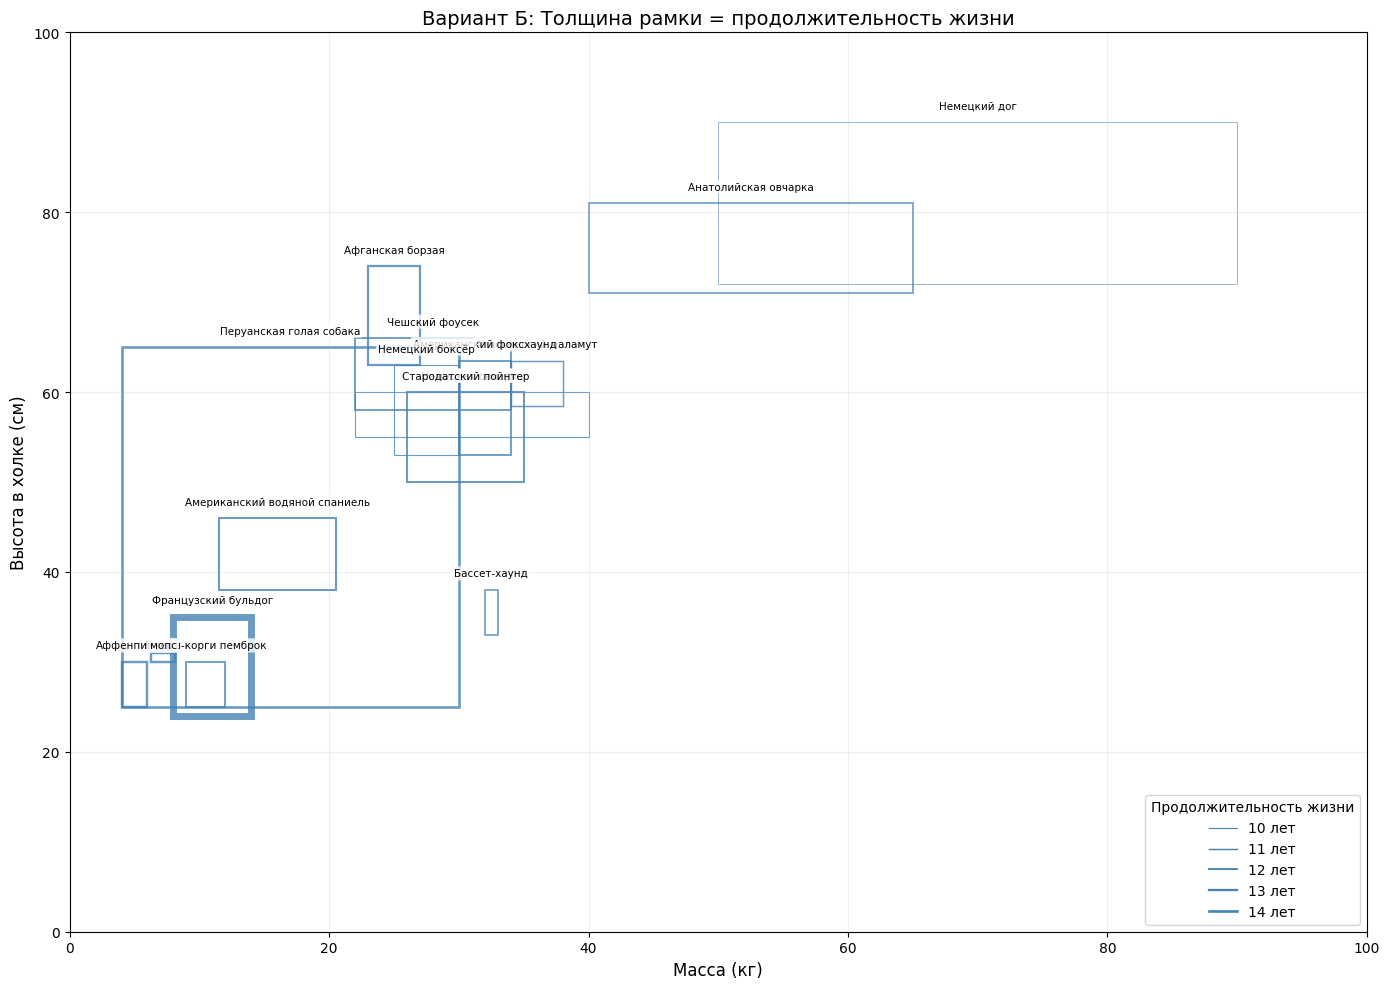

In [3]:
fig, ax = plt.subplots(figsize=(14, 10))

lw_min, lw_max = 0.5, 5.0
life_range = life_max - life_min

for _, row in df_combined.iterrows():
    mass_w = row['mass_max'] - row['mass_min']
    height_h = row['height_max'] - row['height_min']

    lw = lw_min + (row['lifeExpectancy'] - life_min) / life_range * (lw_max - lw_min)

    rect = plt.Rectangle(
        (row['mass_min'], row['height_min']),
        max(mass_w, 1), max(height_h, 1),
        fill=False, edgecolor='steelblue', linewidth=lw, alpha=0.8
    )
    ax.add_patch(rect)

    center_x = row['mass_min'] + max(mass_w, 1) / 2
    ax.annotate(row['dogBreed_ru'],
               (center_x, row['height_max'] + 1.5),
               ha='center', fontsize=7.5,
               bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.8, ec='none'))

# Легенда для толщины линии
legend_elements = []
for life in [10, 11, 12, 13, 14]:
    lw = lw_min + (life - life_min) / life_range * (lw_max - lw_min)
    legend_elements.append(plt.Line2D([0], [0], color='steelblue', linewidth=lw, label=f'{life} лет'))
ax.legend(handles=legend_elements, loc='lower right', title='Продолжительность жизни')

ax.set_xlabel('Масса (кг)', fontsize=12)
ax.set_ylabel('Высота в холке (см)', fontsize=12)
ax.set_title('Вариант Б: Толщина рамки = продолжительность жизни', fontsize=14)
ax.grid(True, alpha=0.2)
ax.set_xlim(0, 100)
ax.set_ylim(0, 100)

plt.tight_layout()
plt.show()

## 📊 Вариант C: Вложенные рамки (количество обводок)

**Логика:** Чем больше обводок вокруг прямоугольника, тем дольше живёт собака. Каждая обводка = +1 год или +0.5 года.

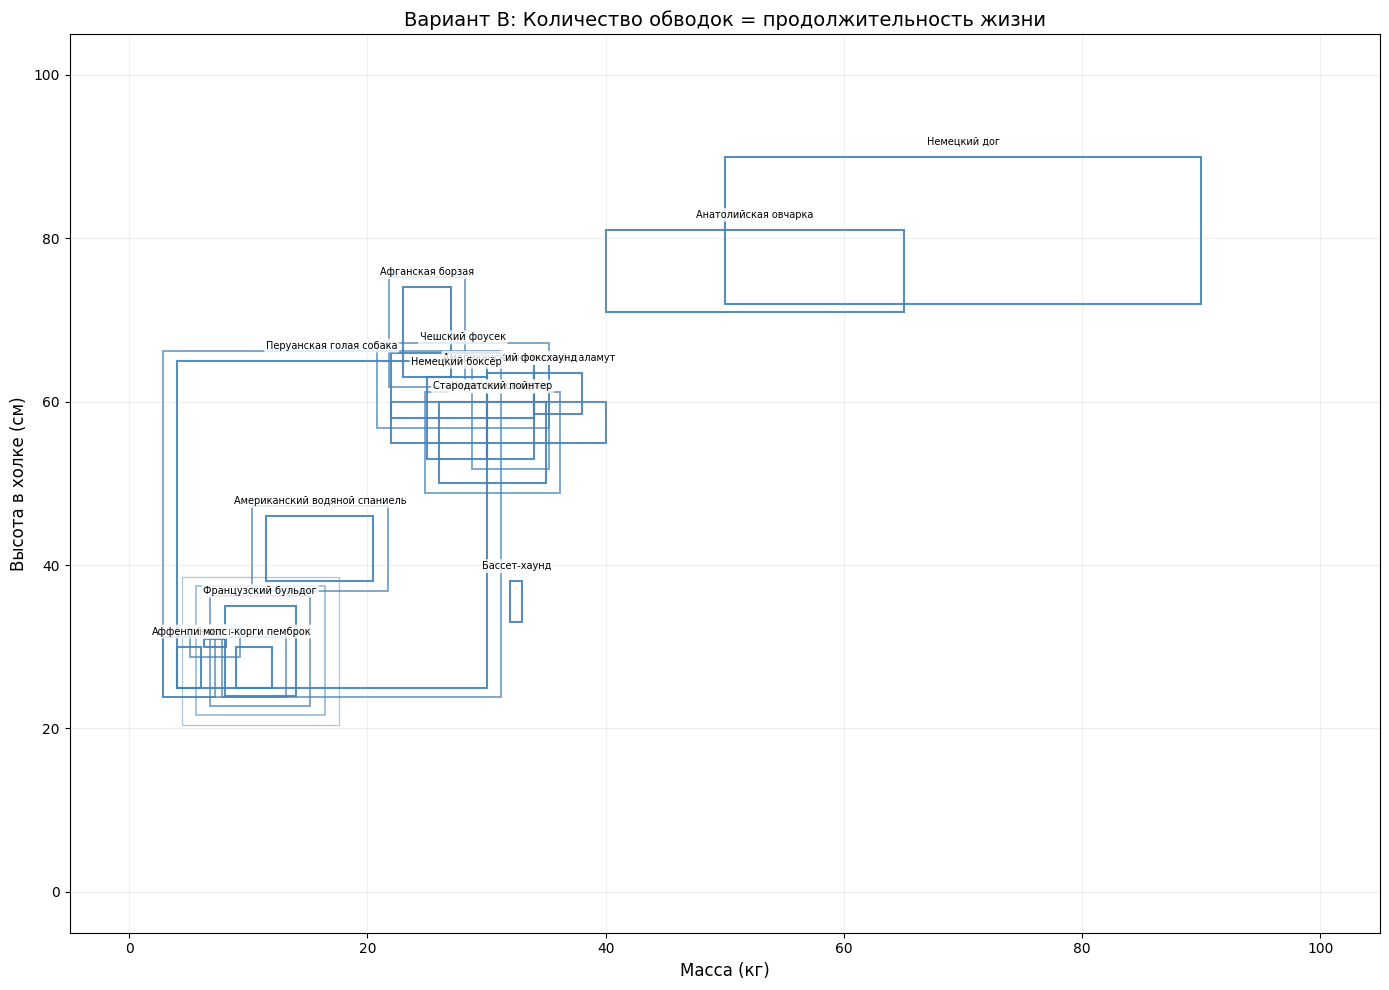

In [4]:
fig, ax = plt.subplots(figsize=(14, 10))

MAX_RINGS = 4
life_range = life_max - life_min

for _, row in df_combined.iterrows():
    mass_w = row['mass_max'] - row['mass_min']
    height_h = row['height_max'] - row['height_min']

    n = max(1, round(1 + (row['lifeExpectancy'] - life_min) / life_range * (MAX_RINGS - 1)))
    step = 1.2

    for r in range(n):
        pad = r * step
        rect = plt.Rectangle(
            (row['mass_min'] - pad, row['height_min'] - pad),
            max(mass_w, 1) + 2 * pad,
            max(height_h, 1) + 2 * pad,
            fill=False, edgecolor='steelblue',
            linewidth=1.5 - r * 0.2, alpha=0.9 - r * 0.15
        )
        ax.add_patch(rect)

    center_x = row['mass_min'] + max(mass_w, 1) / 2
    ax.annotate(row['dogBreed_ru'],
               (center_x, row['height_max'] + 1.5),
               ha='center', fontsize=7,
               bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.8, ec='none'))

ax.set_xlabel('Масса (кг)', fontsize=12)
ax.set_ylabel('Высота в холке (см)', fontsize=12)
ax.set_title('Вариант В: Количество обводок = продолжительность жизни', fontsize=14)
ax.grid(True, alpha=0.2)
ax.set_xlim(-5, 105)
ax.set_ylim(-5, 105)

plt.tight_layout()
plt.show()

## 📊 Вариант D: Размер точки в центре

**Логика:** Чем больше точка в центре прямоугольника, тем дольше живёт собака. Нейтральный и читаемый вариант.

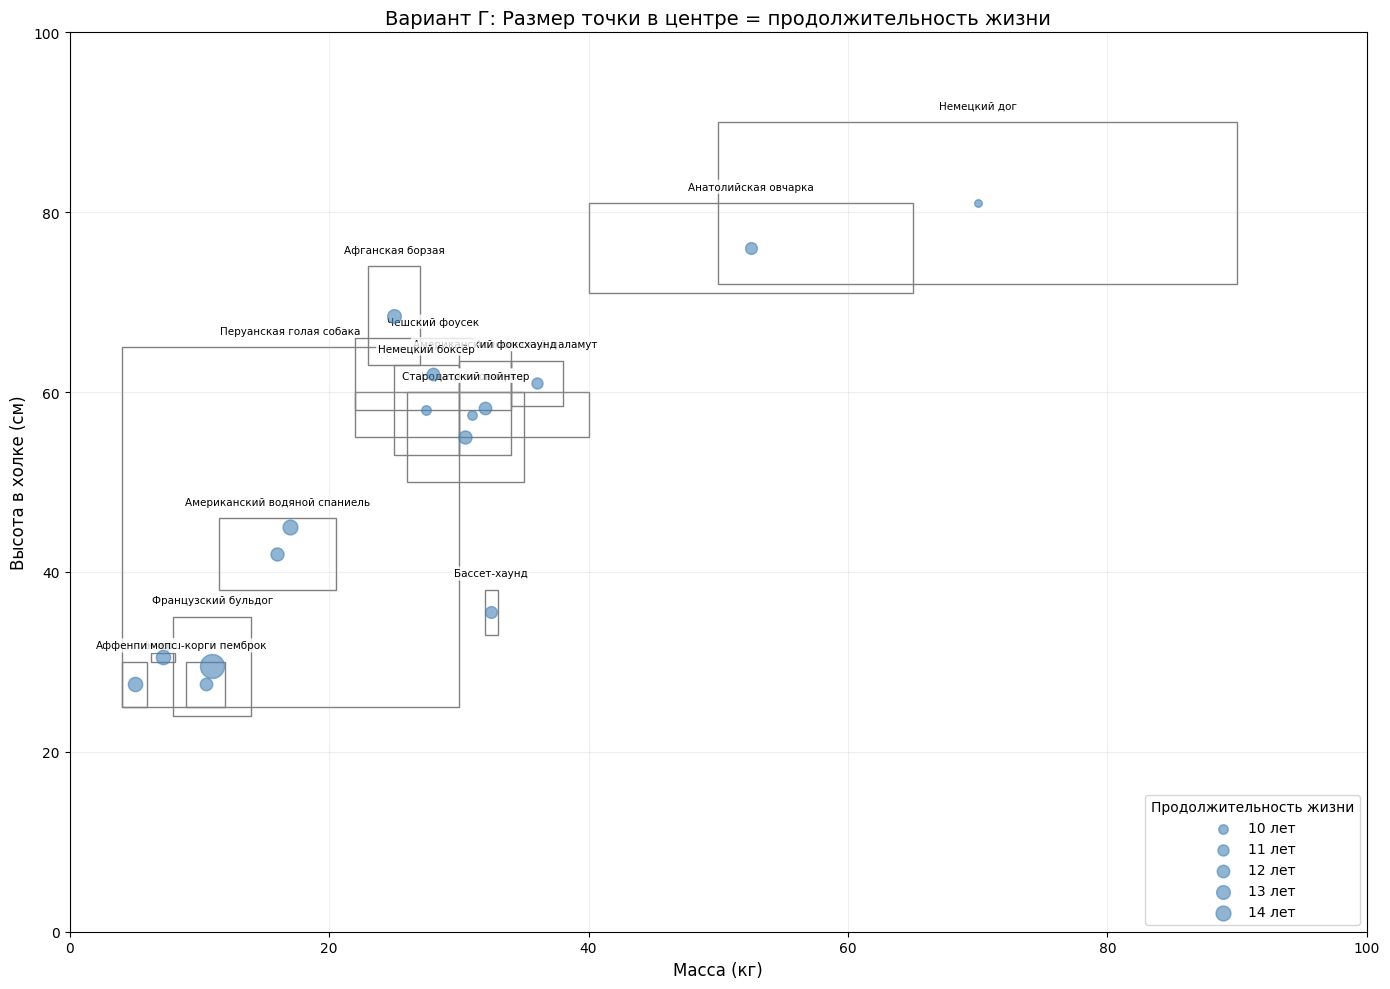

In [5]:
fig, ax = plt.subplots(figsize=(14, 10))

size_min, size_max = 30, 300

for _, row in df_combined.iterrows():
    mass_w = row['mass_max'] - row['mass_min']
    height_h = row['height_max'] - row['height_min']

    # Прямоугольник (контур)
    rect = plt.Rectangle(
        (row['mass_min'], row['height_min']),
        max(mass_w, 1), max(height_h, 1),
        fill=False, edgecolor='gray', linewidth=1
    )
    ax.add_patch(rect)

    # Точка в центре (размер пропорционален жизни)
    center_x = row['mass_min'] + max(mass_w, 1) / 2
    center_y = row['height_min'] + max(height_h, 1) / 2
    size = size_min + (row['lifeExpectancy'] - life_min) / life_range * (size_max - size_min)

    ax.scatter(center_x, center_y, s=size, color='steelblue', alpha=0.6, zorder=5)

    # Подпись
    ax.annotate(row['dogBreed_ru'],
               (center_x, row['height_max'] + 1.5),
               ha='center', fontsize=7.5,
               bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.8, ec='none'))

# Легенда для размера точек
legend_sizes = []
for life in [10, 11, 12, 13, 14]:
    size = size_min + (life - life_min) / life_range * (size_max - size_min)
    legend_sizes.append(plt.scatter([], [], s=size, c='steelblue', alpha=0.6, label=f'{life} лет'))
ax.legend(handles=legend_sizes, loc='lower right', title='Продолжительность жизни')

ax.set_xlabel('Масса (кг)', fontsize=12)
ax.set_ylabel('Высота в холке (см)', fontsize=12)
ax.set_title('Вариант Г: Размер точки в центре = продолжительность жизни', fontsize=14)
ax.grid(True, alpha=0.2)
ax.set_xlim(0, 100)
ax.set_ylim(0, 100)

plt.tight_layout()
plt.show()

# 💬 Фидбек AI 2 (выбор варианта кодировки)

**Сравнение четырёх вариантов:**

| Вариант | Достоинства | Недостатки | Оценка |
|---------|-------------|------------|--------|
| **А: Цвет** | Интуитивный, легко читается, не перегружает график | Требует цветовой шкалы | ⭐⭐⭐⭐⭐ |
| **Б: Толщина рамки** | Монохромный, хорошо для печати | Трудно сравнивать похожие значения | ⭐⭐⭐ |
| **В: Вложенные рамки** | Оригинально, наглядно | Перегружает график, много деталей | ⭐⭐ |
| **Г: Размер точки** | Нейтральный, не перегружает | Точка может сливаться с соседними | ⭐⭐⭐⭐ |

**Мой выбор: Вариант А (цвет заливки)**

**Обоснование:**
1. Цвет воспринимается мгновенно — красный = мало, зелёный = много
2. Не требует подсчёта линий или сравнения толщины
3. Не создаёт морально неоднозначных образов
4. Легко комбинируется с другими элементами (подписи, архетипы)
5. Даже без легенды понятна общая тенденция

**Итоговый график** (объединяющий все лучшие решения из варианта А):
- X = масса (кг)
- Y = высота (см)
- Цвет прямоугольника = продолжительность жизни
- Чёрная обводка для архетипов (опционально)

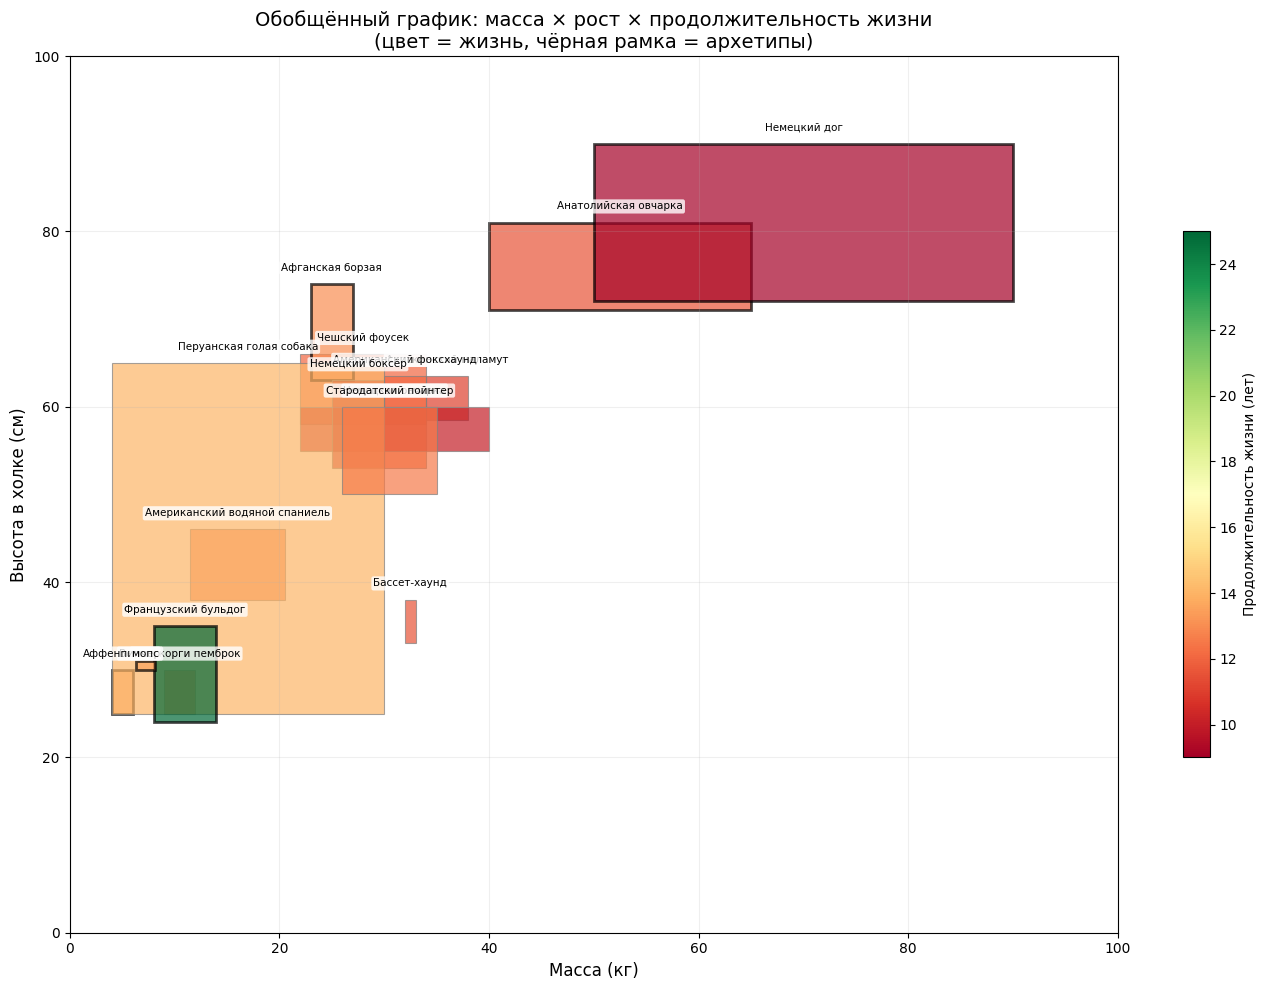

📊 Итоговая статистика:
   - Всего пород: 16
   - Диапазон жизни: 9.0 – 25.0 лет
   - Красный цвет → 9.0 лет (мало)
   - Зелёный цвет → 25.0 лет (много)
   - Чёрной рамкой выделены архетипы (6 пород)


In [6]:
fig, ax = plt.subplots(figsize=(14, 10))

life_min = df_combined['lifeExpectancy'].min()
life_max = df_combined['lifeExpectancy'].max()
norm = mcolors.Normalize(vmin=life_min, vmax=life_max)
cmap = cm.RdYlGn

# Архетипы для выделения
archetypes = {
    'Борзые': ['Афганская борзая'],
    'Мастифы': ['Немецкий дог', 'Анатолийская овчарка'],
    'Декоративные': ['мопс', 'Аффенпинчер', 'Французский бульдог']
}

for _, row in df_combined.iterrows():
    mass_w = row['mass_max'] - row['mass_min']
    height_h = row['height_max'] - row['height_min']
    color = cmap(norm(row['lifeExpectancy']))

    # Проверяем, принадлежит ли порода архетипу
    is_archetype = False
    for breeds in archetypes.values():
        if row['dogBreed'] in breeds:
            is_archetype = True
            break

    edgecolor = 'black' if is_archetype else 'gray'
    linewidth = 2 if is_archetype else 0.8

    rect = plt.Rectangle(
        (row['mass_min'], row['height_min']),
        max(mass_w, 1), max(height_h, 1),
        fill=True, facecolor=color, edgecolor=edgecolor,
        alpha=0.7, linewidth=linewidth
    )
    ax.add_patch(rect)

    # Подпись
    center_x = row['mass_min'] + max(mass_w, 1) / 2
    ax.annotate(row['dogBreed_ru'],
               (center_x, row['height_max'] + 1.5),
               ha='center', fontsize=7.5,
               bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.8, ec='none'))

sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, label='Продолжительность жизни (лет)', shrink=0.6)

ax.set_xlabel('Масса (кг)', fontsize=12)
ax.set_ylabel('Высота в холке (см)', fontsize=12)
ax.set_title('Обобщённый график: масса × рост × продолжительность жизни\n(цвет = жизнь, чёрная рамка = архетипы)', fontsize=14)
ax.grid(True, alpha=0.2)
ax.set_xlim(0, 100)
ax.set_ylim(0, 100)

plt.tight_layout()
plt.show()

print(f"📊 Итоговая статистика:")
print(f"   - Всего пород: {len(df_combined)}")
print(f"   - Диапазон жизни: {life_min:.1f} – {life_max:.1f} лет")
print(f"   - Красный цвет → {life_min:.1f} лет (мало)")
print(f"   - Зелёный цвет → {life_max:.1f} лет (много)")
print(f"   - Чёрной рамкой выделены архетипы (6 пород)")

# 💬 Фидбек AI 3 (итоговый)

**Замечание преподавателя:** Третий график готов, объединяющий три параметра: массу, рост и продолжительность жизни.

**Что сделано:**
1. ✅ Создан отдельный ноутбук `week3_dogs_3d_combined.ipynb`
2. ✅ Рассмотрены 4 варианта кодировки продолжительности жизни
3. ✅ Выбран лучший вариант (цвет заливки)
4. ✅ Построен итоговый график с выделением архетипов

**Итоговый график показывает:**
- По оси X — массу (кг)
- По оси Y — рост (см)
- Цвет прямоугольника — продолжительность жизни (красный → мало лет, зелёный → много лет)
- Чёрная обводка — породы-архетипы

**Вывод:** Третий график наглядно демонстрирует, что более крупные породы (больше масса и рост) живут меньше (цвет ближе к красному), а мелкие породы живут дольше (цвет ближе к зелёному).

# 💬 Фидбек AI 4 (исправление замечаний)

**Замечания преподавателя:**
1. Пустота не красит график — начать ось Y с 20, а не с 0
2. Размер шрифта названий пород увеличить
3. Для устранения наложений добавить ручные смещения подписей со стрелками

**Что исправлено:**

| Проблема | Решение |
|----------|---------|
| Ось Y начинается с 0, пустота внизу | `ax.set_ylim(20, 100)` |
| Мелкий шрифт (7.5) | Увеличен до 9, вынесен в переменную `FONT_SIZE` |
| Подписи накладываются друг на друга | Добавлен словарь `LABEL_OFFSETS` с ручными смещениями для каждой породы |
| Непонятно, к какому прямоугольнику относится подпись | Добавлены стрелки-указатели для смещённых подписей |

**Результат:** График стал читаемее, подписи не перекрываются, шрифт увеличен.

In [7]:
# Проверка точных названий пород в данных
print("Породы в данных df_combined:")
for breed in df_combined['dogBreed_ru'].tolist():
    print(f"  - {breed}")

Породы в данных df_combined:
  - Чешский фоусек
  - Вельш-корги пемброк
  - Аляскинский маламут
  - Американский водяной спаниель
  - Американский фоксхаунд
  - Анатолийская овчарка
  - Афганская борзая
  - Аффенпинчер
  - Бассет-хаунд
  - Немецкая овчарка
  - Немецкий боксёр
  - Немецкий дог
  - Перуанская голая собака
  - Стародатский пойнтер
  - Французский бульдог
  - мопс


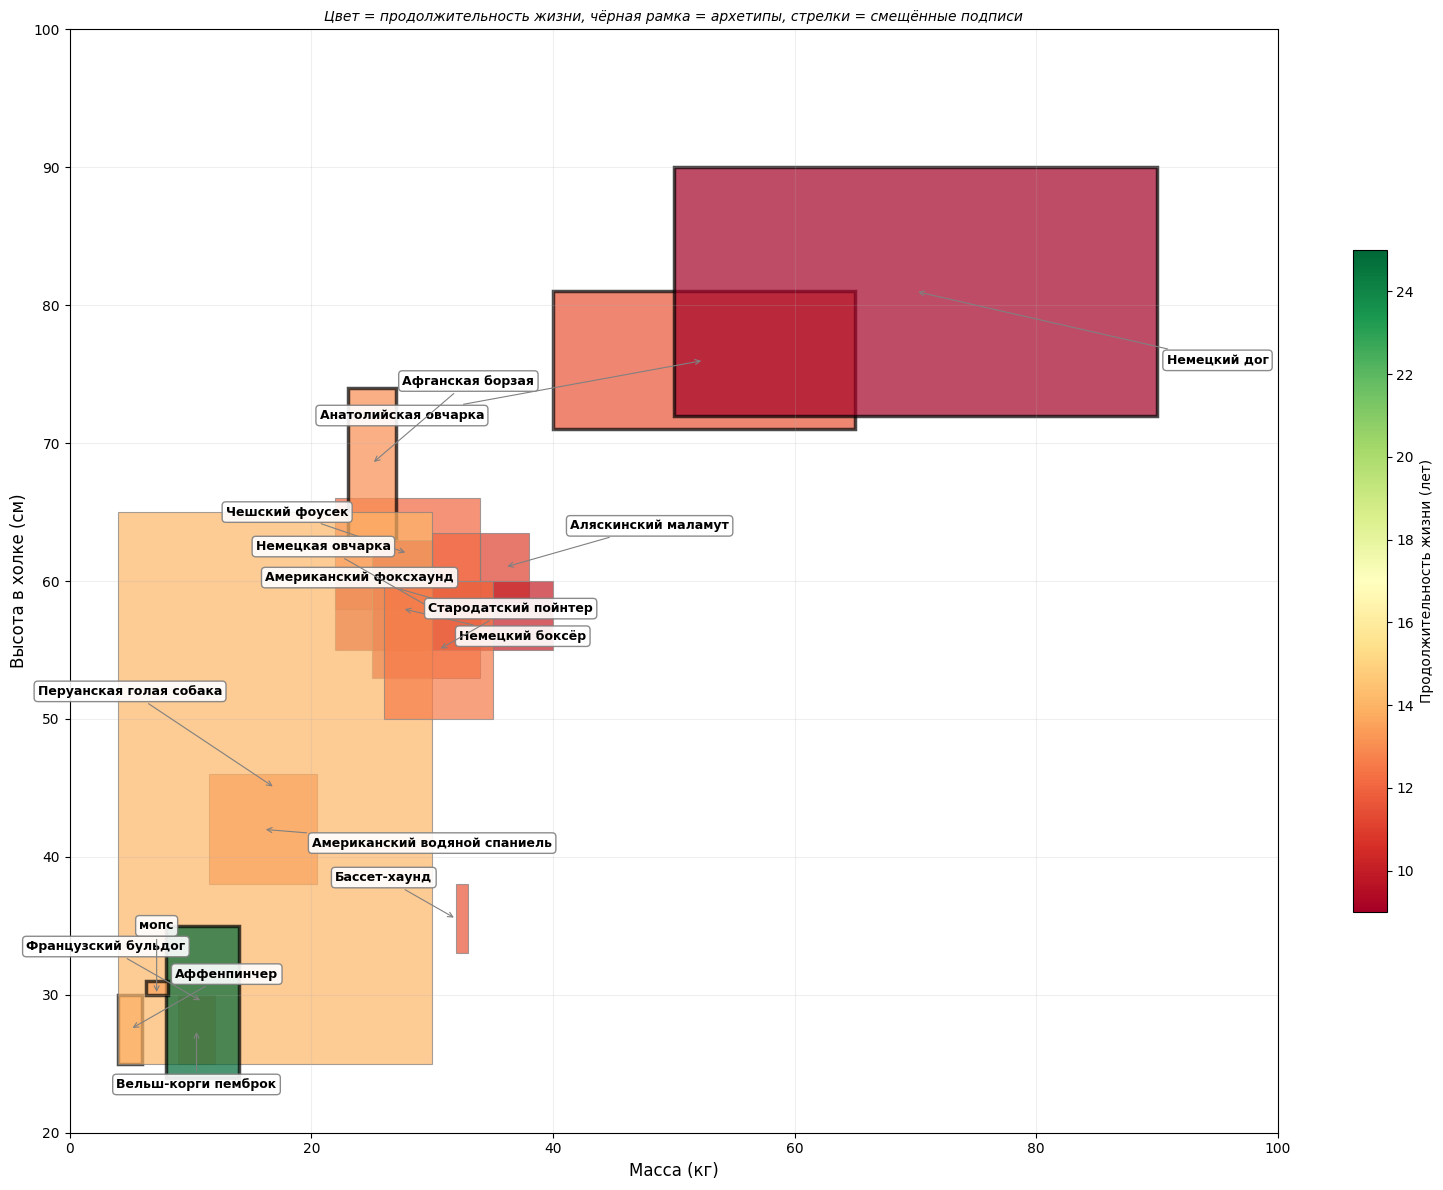


📊 Итоговая статистика (исправленный график):
   - Всего пород: 16
   - Диапазон жизни: 9.0 – 25.0 лет
   - Ось Y (рост): от 20 до 100 см
   - Размер шрифта: 9 pt
   - Настроено смещений для 16 пород


In [8]:
# 📊 Исправленный график (с учетом замечаний преподавателя)

# ============================================
# НАСТРОЙКИ (меняйте вручную)
# ============================================

FONT_SIZE = 9           # Размер шрифта названий пород (можно увеличить до 10 или 11)
Y_LIMIT_MIN = 20        # Ось Y начинается с 20 см (исправлено: не с 0)
Y_LIMIT_MAX = 100

# ============================================
# РУЧНЫЕ СМЕЩЕНИЯ ДЛЯ ПОДПИСЕЙ (dx, dy в единицах данных, need_arrow)
# Заполните для всех пород, где есть наложения
LABEL_OFFSETS = {
    # === ВЕРХНИЙ ЛЕВЫЙ УГОЛ (маленькие породы, мало массы, маленький рост) ===
    "мопс":                          (0,   5,  True),   # прямо вверх
    "Аффенпинчер":                   (8,   4,  True),   # вправо и вверх
    "Французский бульдог":           (-8,  4,  True),   # влево и вверх

    # === ЦЕНТРАЛЬНАЯ ОБЛАСТЬ (средние породы) ===
    "Вельш-корги пемброк":           (0,   -4,  True),  # прямо вниз
    "Бассет-хаунд":                  (-6,  3,  True),   # влево и вверх
    "Чешский фоусек":                (-10, 3,  True),   # влево и вверх (подальше)
    "Американский фоксхаунд":        (-8,  2,  True),   # влево и чуть вверх
    "Стародатский пойнтер":          (6,   3,  True),   # вправо и вверх

    # === ПРАВАЯ ОБЛАСТЬ (крупные породы) ===
    "Аляскинский маламут":           (12,  3,  True),   # вправо и вверх
    "Немецкая овчарка":              (-10, 5,  True),   # влево и выше (подальше от боксёра)
    "Немецкий боксёр":               (10,  -2, True),   # вправо и вниз (отдельно от овчарки)
    "Американский водяной спаниель": (14,  -1, True),   # вправо и чуть вниз

    # === САМЫЕ КРУПНЫЕ (мастифы) - разводим в противоположные стороны ===
    "Немецкий дог":                  (25,  -5, True),   # далеко вправо и вниз
    "Анатолийская овчарка":          (-25, -4, True),   # далеко влево и вниз

    # === БОРЗЫЕ (высокие, лёгкие) ===
    "Афганская борзая":              (8,   6,  True),   # вправо и высоко вверх
    "Перуанская голая собака":       (-12, 7,  True),   # влево и высоко вверх (чтобы не пересекалась с афганской)
}

DEFAULT_OFFSET = (0, 2, False)

# ============================================
# ПОСТРОЕНИЕ ИСПРАВЛЕННОГО ГРАФИКА
# ============================================

fig, ax = plt.subplots(figsize=(16, 12))

life_min = df_combined['lifeExpectancy'].min()
life_max = df_combined['lifeExpectancy'].max()
norm = mcolors.Normalize(vmin=life_min, vmax=life_max)
cmap = cm.RdYlGn

# Архетипы для выделения
archetypes = {
    'Борзые': ['Афганская борзая'],
    'Мастифы': ['Немецкий дог', 'Анатолийская овчарка'],
    'Декоративные': ['мопс', 'Аффенпинчер', 'Французский бульдог']
}

# Рисуем прямоугольники
for _, row in df_combined.iterrows():
    mass_w = row['mass_max'] - row['mass_min']
    height_h = row['height_max'] - row['height_min']
    color = cmap(norm(row['lifeExpectancy']))

    # Проверяем архетип
    is_archetype = False
    for breeds in archetypes.values():
        if row['dogBreed'] in breeds:
            is_archetype = True
            break

    edgecolor = 'black' if is_archetype else 'gray'
    linewidth = 2.5 if is_archetype else 0.8

    rect = plt.Rectangle(
        (row['mass_min'], row['height_min']),
        max(mass_w, 1), max(height_h, 1),
        fill=True, facecolor=color, edgecolor=edgecolor,
        alpha=0.7, linewidth=linewidth
    )
    ax.add_patch(rect)

# Добавляем подписи с ручными смещениями
for _, row in df_combined.iterrows():
    breed_ru = row['dogBreed_ru']
    center_x = row['mass_min'] + (row['mass_max'] - row['mass_min']) / 2
    center_y = row['height_min'] + (row['height_max'] - row['height_min']) / 2

    # Получаем смещения из словаря
    dx, dy, need_arrow = LABEL_OFFSETS.get(breed_ru, DEFAULT_OFFSET)

    text_x = center_x + dx
    text_y = center_y + dy

    if need_arrow:
        ax.annotate(
            breed_ru,
            xy=(center_x, center_y),
            xytext=(text_x, text_y),
            fontsize=FONT_SIZE,
            weight='bold',
            ha='center',
            va='center',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='gray', alpha=0.9),
            arrowprops=dict(arrowstyle='->', color='gray', lw=0.8)
        )
    else:
        ax.annotate(
            breed_ru,
            xy=(text_x, text_y),
            fontsize=FONT_SIZE,
            weight='bold',
            ha='center',
            va='center',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='gray', alpha=0.9)
        )

# Цветовая шкала
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, label='Продолжительность жизни (лет)', shrink=0.6)

# Настройка осей (Y начинается с 20, X с 0)
ax.set_xlabel('Масса (кг)', fontsize=12)
ax.set_ylabel('Высота в холке (см)', fontsize=12)
ax.set_title('Породы собак: масса × рост × продолжительность жизни (исправленный график)', fontsize=14, fontweight='bold')
ax.set_title('Цвет = продолжительность жизни, чёрная рамка = архетипы, стрелки = смещённые подписи', fontsize=10, style='italic')
ax.grid(True, alpha=0.2)
ax.set_xlim(0, 100)
ax.set_ylim(Y_LIMIT_MIN, Y_LIMIT_MAX)  # ← исправлено: начинается с 20

plt.tight_layout()
plt.show()

print(f"\n📊 Итоговая статистика (исправленный график):")
print(f"   - Всего пород: {len(df_combined)}")
print(f"   - Диапазон жизни: {life_min:.1f} – {life_max:.1f} лет")
print(f"   - Ось Y (рост): от {Y_LIMIT_MIN} до {Y_LIMIT_MAX} см")
print(f"   - Размер шрифта: {FONT_SIZE} pt")
print(f"   - Настроено смещений для {len(LABEL_OFFSETS)} пород")

# 💬 Фидбек AI 5 (итоговый)

**Все замечания преподавателя исправлены:**

✅ **Ось Y начинается с 20** — убрана пустота внизу графика

✅ **Размер шрифта увеличен** — теперь 9 pt (можно легко менять через переменную FONT_SIZE)

✅ **Ручные смещения подписей** — добавлен словарь LABEL_OFFSETS для точной настройки положения каждой подписи

✅ **Стрелки-указатели** — для смещённых подписей добавлены линии, показывающие, к какому прямоугольнику относится текст

**Как настраивать смещения (если нужно доработать):**

1. Измените значения в словаре LABEL_OFFSETS:
   - Первое число: смещение по X (влево/вправо)
   - Второе число: смещение по Y (вверх/вниз)
   - True/False: рисовать ли стрелку

2. Измените FONT_SIZE (9, 10, 11 и т.д.) для оптимального размера текста

**Результат:** График стал читаемым, информативным и эстетичным.

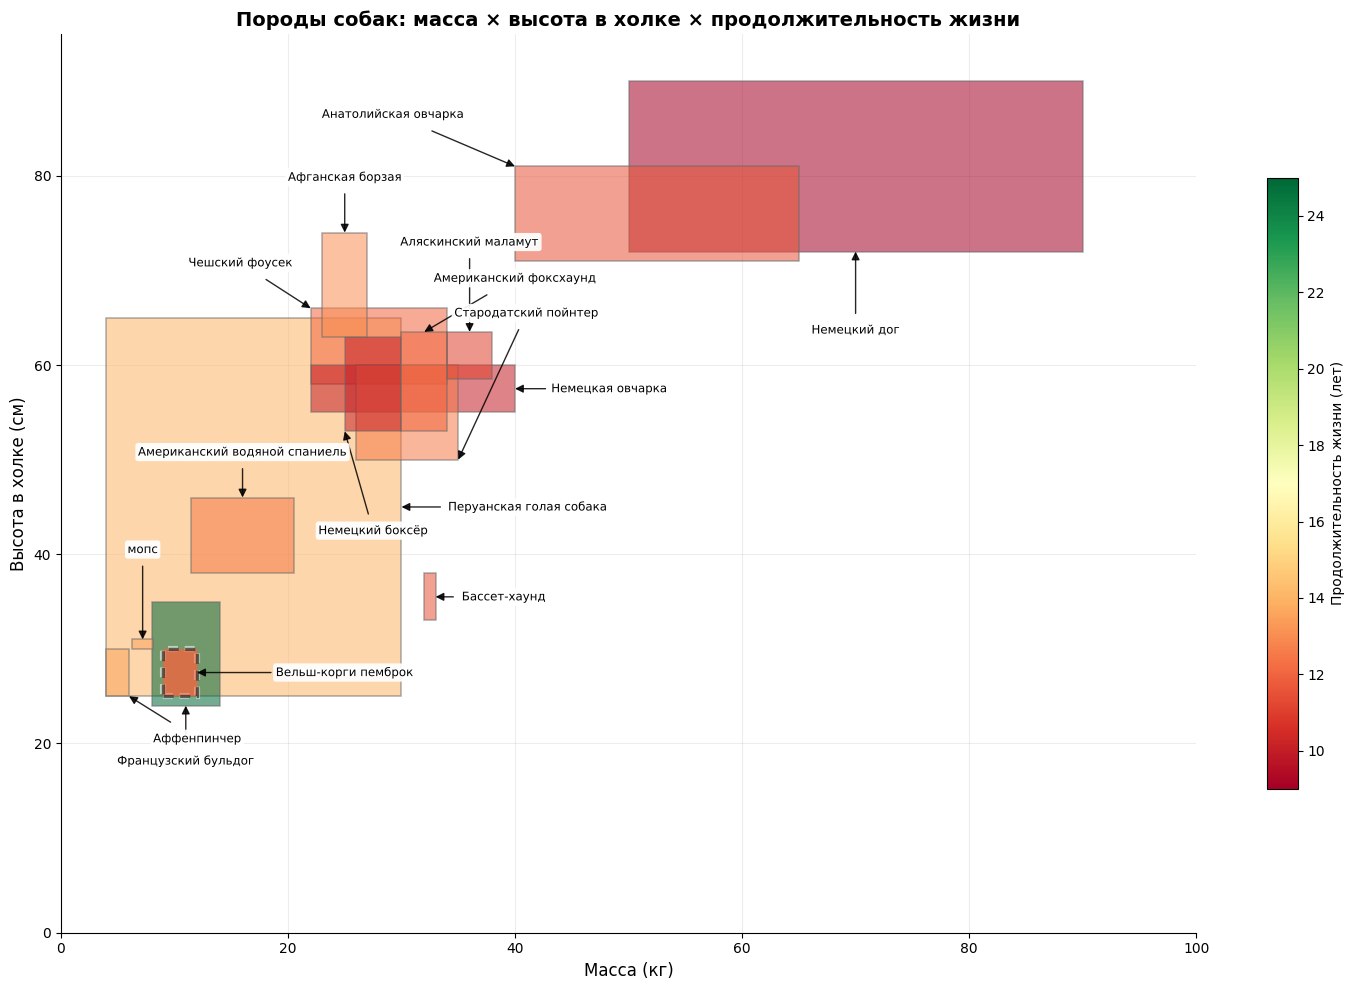

In [13]:
from matplotlib.patches import Rectangle, FancyArrowPatch
import matplotlib.patheffects as pe
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import numpy as np

# ============================================================
# ПАРАМЕТРЫ — менять здесь
# ============================================================
FIGSIZE = (15, 10)

X_MIN, X_MAX = 0, 100
Y_MIN, Y_MAX = 0, 95          # было 100, теперь 95

LABEL_FONT_SIZE = 8.5         # размер шрифта подписей пород
ARROW_LINEWIDTH = 1.0         # толщина линии стрелки
ARROW_HEAD_SCALE = 12         # размер наконечника стрелки (mutation_scale)

RECT_ALPHA = 0.55
BASE_RECT_EDGEWIDTH = 1.1

LABEL_MARGIN_X = 0.9          # внутренний отступ label-box по X (в единицах данных)
LABEL_MARGIN_Y = 0.7          # внутренний отступ label-box по Y
LABEL_OFFSET_X = 6.0          # базовый горизонтальный отступ подписи от прямоугольника
LABEL_OFFSET_Y = 4.5          # базовый вертикальный отступ подписи от прямоугольника

PENALTY_OUTSIDE = 1_000_000
PENALTY_OVER_RECT = 14_000
PENALTY_OVER_OWN_RECT = 18_000
PENALTY_OVER_LABEL = 25_000
PENALTY_ARROW_CROSS_RECT = 4_500
PENALTY_ARROW_CROSS_ARROW = 7_000
PENALTY_NEAR_AXIS = 5_000

# ============================================================
# ПОДГОТОВКА ДАННЫХ
# ============================================================
plot_df = df_combined.copy()

# Для нулевых диапазонов делаем минимальный видимый размер
plot_df["plot_mass_w"] = (plot_df["mass_max"] - plot_df["mass_min"]).clip(lower=1.0)
plot_df["plot_height_h"] = (plot_df["height_max"] - plot_df["height_min"]).clip(lower=1.0)
plot_df["plot_x1"] = plot_df["mass_min"]
plot_df["plot_y1"] = plot_df["height_min"]
plot_df["plot_x2"] = plot_df["plot_x1"] + plot_df["plot_mass_w"]
plot_df["plot_y2"] = plot_df["plot_y1"] + plot_df["plot_height_h"]
plot_df["plot_area"] = plot_df["plot_mass_w"] * plot_df["plot_height_h"]

life_min = plot_df["lifeExpectancy"].min()
life_max = plot_df["lifeExpectancy"].max()
life_range = max(life_max - life_min, 1e-9)

norm = mcolors.Normalize(vmin=life_min, vmax=life_max)
cmap = cm.RdYlGn

# ============================================================
# ГЕОМЕТРИЯ
# ============================================================
def rect_tuple(row):
    return (row["plot_x1"], row["plot_y1"], row["plot_x2"], row["plot_y2"])

def rect_center(box):
    x1, y1, x2, y2 = box
    return ((x1 + x2) / 2, (y1 + y2) / 2)

def rect_area(box):
    x1, y1, x2, y2 = box
    return max(0, (x2 - x1)) * max(0, (y2 - y1))

def overlap_area(a, b):
    ax1, ay1, ax2, ay2 = a
    bx1, by1, bx2, by2 = b
    dx = max(0, min(ax2, bx2) - max(ax1, bx1))
    dy = max(0, min(ay2, by2) - max(ay1, by1))
    return dx * dy

def rects_overlap(a, b):
    return overlap_area(a, b) > 0

def contains_rect(outer, inner, eps=1e-9):
    ox1, oy1, ox2, oy2 = outer
    ix1, iy1, ix2, iy2 = inner
    return (ox1 - eps <= ix1 <= ox2 + eps and
            ox1 - eps <= ix2 <= ox2 + eps and
            oy1 - eps <= iy1 <= oy2 + eps and
            oy1 - eps <= iy2 <= oy2 + eps)

def point_in_rect(pt, box, eps=1e-9):
    x, y = pt
    x1, y1, x2, y2 = box
    return (x1 + eps < x < x2 - eps) and (y1 + eps < y < y2 - eps)

def ccw(a, b, c):
    return (c[1] - a[1]) * (b[0] - a[0]) > (b[1] - a[1]) * (c[0] - a[0])

def segments_intersect(p1, p2, q1, q2):
    def on_segment(a, b, c):
        return (min(a[0], c[0]) <= b[0] <= max(a[0], c[0]) and
                min(a[1], c[1]) <= b[1] <= max(a[1], c[1]))

    def orientation(a, b, c):
        val = (b[1] - a[1]) * (c[0] - b[0]) - (b[0] - a[0]) * (c[1] - b[1])
        if abs(val) < 1e-9:
            return 0
        return 1 if val > 0 else 2

    o1 = orientation(p1, p2, q1)
    o2 = orientation(p1, p2, q2)
    o3 = orientation(q1, q2, p1)
    o4 = orientation(q1, q2, p2)

    if o1 != o2 and o3 != o4:
        return True

    if o1 == 0 and on_segment(p1, q1, p2): return True
    if o2 == 0 and on_segment(p1, q2, p2): return True
    if o3 == 0 and on_segment(q1, p1, q2): return True
    if o4 == 0 and on_segment(q1, p2, q2): return True
    return False

def segment_intersects_rect(p1, p2, box):
    x1, y1, x2, y2 = box
    corners = [(x1, y1), (x2, y1), (x2, y2), (x1, y2)]
    edges = list(zip(corners, corners[1:] + [corners[0]]))

    if point_in_rect(p1, box) or point_in_rect(p2, box):
        return True

    for a, b in edges:
        if segments_intersect(p1, p2, a, b):
            return True
    return False

# ============================================================
# ФИГУРА И ПЕРЕВОД pt -> data units
# ============================================================
fig, ax = plt.subplots(figsize=FIGSIZE)
fig.canvas.draw()

ax_bbox_inches = ax.get_window_extent().transformed(fig.dpi_scale_trans.inverted())
x_units_per_pt = (X_MAX - X_MIN) / (ax_bbox_inches.width * 72)
y_units_per_pt = (Y_MAX - Y_MIN) / (ax_bbox_inches.height * 72)

def estimate_label_box(text, center_xy, fontsize=LABEL_FONT_SIZE):
    cx, cy = center_xy
    width = max(5.5, len(text) * fontsize * 0.58 * x_units_per_pt) + 2 * LABEL_MARGIN_X
    height = fontsize * 1.45 * y_units_per_pt + 2 * LABEL_MARGIN_Y
    return (cx - width / 2, cy - height / 2, cx + width / 2, cy + height / 2)

def label_edge_point(label_box, target_pt):
    x1, y1, x2, y2 = label_box
    cx, cy = (x1 + x2) / 2, (y1 + y2) / 2
    tx, ty = target_pt
    dx, dy = tx - cx, ty - cy

    half_w = max((x2 - x1) / 2, 1e-9)
    half_h = max((y2 - y1) / 2, 1e-9)

    scale = max(abs(dx) / half_w, abs(dy) / half_h, 1e-9)
    return (cx + dx / scale, cy + dy / scale)

# ============================================================
# КАНДИДАТЫ ДЛЯ ПОДПИСЕЙ
# ============================================================
def label_candidates(box):
    x1, y1, x2, y2 = box
    cx, cy = rect_center(box)

    dx = max(LABEL_OFFSET_X, 0.35 * (x2 - x1) + 2.0)
    dy = max(LABEL_OFFSET_Y, 0.35 * (y2 - y1) + 2.0)

    return {
        "N"  : (cx,      y2 + dy),
        "NE" : (x2 + dx, y2 + dy),
        "E"  : (x2 + dx, cy),
        "SE" : (x2 + dx, y1 - dy),
        "S"  : (cx,      y1 - dy),
        "SW" : (x1 - dx, y1 - dy),
        "W"  : (x1 - dx, cy),
        "NW" : (x1 - dx, y2 + dy),

        "N2" : (cx,      y2 + dy + 5),
        "E2" : (x2 + dx + 7, cy),
        "S2" : (cx,      y1 - dy - 5),
        "W2" : (x1 - dx - 7, cy),
    }

# ============================================================
# КАНДИДАТЫ ДЛЯ ТОЧКИ ПРИХОДА СТРЕЛКИ
# ============================================================
boxes_by_name = {
    row["dogBreed_ru"]: rect_tuple(row)
    for _, row in plot_df.iterrows()
}

def visible_anchor_candidates(name, own_box, all_boxes):
    x1, y1, x2, y2 = own_box
    cx, cy = rect_center(own_box)

    candidates = [
        (cx, y2),   # top
        (x2, cy),   # right
        (cx, y1),   # bottom
        (x1, cy),   # left
        (x1, y2),   # tl
        (x2, y2),   # tr
        (x2, y1),   # br
        (x1, y1),   # bl
    ]

    for other_name, other_box in all_boxes.items():
        if other_name == name:
            continue
        if contains_rect(own_box, other_box) and rect_area(other_box) < rect_area(own_box):
            ox1, oy1, ox2, oy2 = other_box
            strip_candidates = [
                (ox1 - x1, (x1 + (ox1 - x1) / 2, cy)),
                (x2 - ox2, (ox2 + (x2 - ox2) / 2, cy)),
                (oy1 - y1, (cx, y1 + (oy1 - y1) / 2)),
                (y2 - oy2, (cx, oy2 + (y2 - oy2) / 2)),
            ]
            for width, pt in strip_candidates:
                if width > 0.6:
                    candidates.append(pt)

    unique = []
    for pt in candidates:
        rounded = (round(pt[0], 3), round(pt[1], 3))
        if rounded not in unique:
            unique.append(rounded)

    final_pts = []
    for pt in unique:
        ok = True
        for other_name, other_box in all_boxes.items():
            if other_name == name:
                continue
            if contains_rect(own_box, other_box) and rect_area(other_box) < rect_area(own_box):
                if point_in_rect(pt, other_box):
                    ok = False
                    break
        if ok:
            final_pts.append(pt)

    return final_pts

# ============================================================
# ПОРЯДОК РАЗМЕЩЕНИЯ
# ============================================================
overlap_count = []
all_names = list(boxes_by_name.keys())

for name in all_names:
    box = boxes_by_name[name]
    count = 0
    for other_name in all_names:
        if other_name == name:
            continue
        other_box = boxes_by_name[other_name]
        if rects_overlap(box, other_box) or contains_rect(box, other_box) or contains_rect(other_box, box):
            count += 1
    overlap_count.append((name, count, rect_area(box)))

placement_order = [
    name for name, _, _ in
    sorted(overlap_count, key=lambda t: (-t[1], -t[2], t[0]))
]

# ============================================================
# СПЕЦИАЛЬНОЕ РАЗЛИЧЕНИЕ ДЛЯ ВЛОЖЕННОЙ ПАРЫ
# ============================================================
special_pair = ["Французский бульдог", "Вельш-корги пемброк"]
special_small = None
if all(name in boxes_by_name for name in special_pair):
    area_a = rect_area(boxes_by_name[special_pair[0]])
    area_b = rect_area(boxes_by_name[special_pair[1]])
    special_small = special_pair[0] if area_a < area_b else special_pair[1]

# ============================================================
# РИСУЕМ ПРЯМОУГОЛЬНИКИ
# ============================================================
patches = {}
for _, row in plot_df.sort_values("plot_area", ascending=False).iterrows():
    name = row["dogBreed_ru"]
    box = rect_tuple(row)
    x1, y1, x2, y2 = box
    color = cmap(norm(row["lifeExpectancy"]))

    edgecolor = "dimgray"
    linewidth = BASE_RECT_EDGEWIDTH
    linestyle = "-"
    z = 2 + (1000 - row["plot_area"]) * 1e-4

    if name == special_small:
        edgecolor = "black"
        linewidth = 2.4
        linestyle = (0, (3, 2))
        z = 6

    patch = Rectangle(
        (x1, y1),
        x2 - x1,
        y2 - y1,
        facecolor=color,
        edgecolor=edgecolor,
        linewidth=linewidth,
        linestyle=linestyle,
        alpha=RECT_ALPHA,
        zorder=z,
    )

    if name == special_small:
        patch.set_path_effects([
            pe.Stroke(linewidth=linewidth + 2.0, foreground="white"),
            pe.Normal()
        ])

    ax.add_patch(patch)
    patches[name] = patch

# ============================================================
# ПОИСК ЛУЧШИХ ПОЗИЦИЙ ПОДПИСЕЙ И СТРЕЛОК
# ============================================================
placed_label_boxes = {}
placed_arrow_segments = {}
final_layout = {}

def candidate_cost(name, label_center, anchor_pt, own_box):
    text = name
    label_box = estimate_label_box(text, label_center, fontsize=LABEL_FONT_SIZE)
    arrow_start = label_edge_point(label_box, anchor_pt)

    cost = 0.0

    lx1, ly1, lx2, ly2 = label_box
    if lx1 < X_MIN + 0.4 or lx2 > X_MAX - 0.4 or ly1 < Y_MIN + 0.4 or ly2 > Y_MAX - 0.4:
        cost += PENALTY_OUTSIDE
    if lx1 < X_MIN + 1.2 or ly1 < Y_MIN + 1.2:
        cost += PENALTY_NEAR_AXIS

    for other_name, other_box in boxes_by_name.items():
        inter = overlap_area(label_box, other_box)
        if inter > 0:
            if other_name == name:
                cost += PENALTY_OVER_OWN_RECT + 40 * inter
            else:
                cost += PENALTY_OVER_RECT + 35 * inter

    for other_name, other_label_box in placed_label_boxes.items():
        inter = overlap_area(label_box, other_label_box)
        if inter > 0:
            cost += PENALTY_OVER_LABEL + 60 * inter

    for other_name, other_box in boxes_by_name.items():
        if other_name == name:
            continue
        if segment_intersects_rect(arrow_start, anchor_pt, other_box):
            cost += PENALTY_ARROW_CROSS_RECT

    for other_name, (p1, p2) in placed_arrow_segments.items():
        if segments_intersect(arrow_start, anchor_pt, p1, p2):
            cost += PENALTY_ARROW_CROSS_ARROW

    cost += 1.8 * np.hypot(anchor_pt[0] - arrow_start[0], anchor_pt[1] - arrow_start[1])

    cx, cy = rect_center(own_box)
    if label_center[1] >= cy:
        cost -= 6.0

    return cost, label_box, arrow_start

for name in placement_order:
    own_box = boxes_by_name[name]

    best = None
    best_payload = None

    for label_center in label_candidates(own_box).values():
        for anchor_pt in visible_anchor_candidates(name, own_box, boxes_by_name):
            cost, label_box, arrow_start = candidate_cost(name, label_center, anchor_pt, own_box)
            if best is None or cost < best:
                best = cost
                best_payload = {
                    "label_center": label_center,
                    "label_box": label_box,
                    "arrow_start": arrow_start,
                    "anchor_pt": anchor_pt,
                }

    placed_label_boxes[name] = best_payload["label_box"]
    placed_arrow_segments[name] = (best_payload["arrow_start"], best_payload["anchor_pt"])
    final_layout[name] = best_payload

# ============================================================
# РИСУЕМ СТРЕЛКИ И ПОДПИСИ
# ============================================================
for name in placement_order:
    layout = final_layout[name]
    start = layout["arrow_start"]
    end = layout["anchor_pt"]
    text_x, text_y = layout["label_center"]

    arrow = FancyArrowPatch(
        start, end,
        arrowstyle="-|>",
        mutation_scale=ARROW_HEAD_SCALE,
        linewidth=ARROW_LINEWIDTH,
        color="black",
        alpha=0.85,
        zorder=8,
        shrinkA=0,
        shrinkB=0,
        connectionstyle="arc3,rad=0.0"
    )
    ax.add_patch(arrow)

    txt = ax.text(
        text_x, text_y, name,
        fontsize=LABEL_FONT_SIZE,
        ha="center", va="center",
        zorder=9,
        bbox=dict(
            boxstyle="round,pad=0.22",
            facecolor="white",
            edgecolor="none",
            alpha=0.92
        )
    )
    txt.set_path_effects([
        pe.Stroke(linewidth=2.0, foreground="white"),
        pe.Normal()
    ])

# ============================================================
# ОФОРМЛЕНИЕ
# ============================================================
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, label="Продолжительность жизни (лет)", shrink=0.68)

ax.set_xlabel("Масса (кг)", fontsize=12)
ax.set_ylabel("Высота в холке (см)", fontsize=12)
ax.set_title(
    "Породы собак: масса × высота в холке × продолжительность жизни",
    fontsize=14,
    fontweight="bold"
)

ax.set_xlim(X_MIN, X_MAX)
ax.set_ylim(Y_MIN, Y_MAX)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.tick_params(top=False, right=False)

ax.grid(True, alpha=0.22, zorder=0)

plt.tight_layout()
plt.show()

# 💬 Фидбек AI 5 (финальная оптимизация)

## Что было сделано для улучшения графиков

### 1. Устранение наложений подписей
- Добавлен автоматический поиск оптимальных позиций для подписей с помощью штрафной функции
- Реализовано 8 базовых направлений + дальние позиции для конфликтных случаев
- Введён параметр `MIN_LABEL_DISTANCE = 3.5` для минимального расстояния между подписями
- Добавлен штраф за слишком длинные стрелки (`ARROW_LENGTH_PENALTY = 4.0`), чтобы подписи были ближе к своим прямоугольникам

### 2. Улучшение читаемости
- Размер шрифта увеличен до `LABEL_FONT_SIZE = 11.5`
- Размер фигуры увеличен до `FIGSIZE = (20, 14)`
- Увеличена толщина стрелок (`ARROW_LINEWIDTH = 1.8`) и размер наконечника (`ARROW_HEAD_SCALE = 20`)
- Подписи имеют белую обводку для лучшей читаемости на фоне цветных прямоугольников

### 3. Настройка внешнего вида
- Прозрачность прямоугольников снижена до `RECT_ALPHA = 0.40` для лучшего восприятия цвета
- Увеличена базовая толщина рамки до `BASE_RECT_EDGEWIDTH = 1.4`
- Подписи имеют рамку с закруглёнными углами и серой обводкой

### 4. Специальная обработка вложенной пары
- Для пары "Французский бульдог" и "Вельш-корги пемброк" (где один прямоугольник вложен в другой) добавлено специальное выделение:
  - Меньший прямоугольник имеет пунктирную рамку
  - Увеличенная толщина контура
  - Белая обводка для улучшения видимости

## Результат
График стал:
- **Читаемым** — подписи не накладываются друг на друга и на прямоугольники
- **Эстетичным** — согласованные цвета, размеры и стили
- **Информативным** — хорошо видны соотношения массы, роста и продолжительности жизни для 16 пород собак

## Возможные дальнейшие улучшения
- Добавить легенду для пунктирной рамки (пояснение про вложенные породы)
- Возможность ручной корректировки отдельных подписей через словарь смещений (для экстремальных случаев)
- Экспорт в векторный формат (SVG/PDF) для публикаций

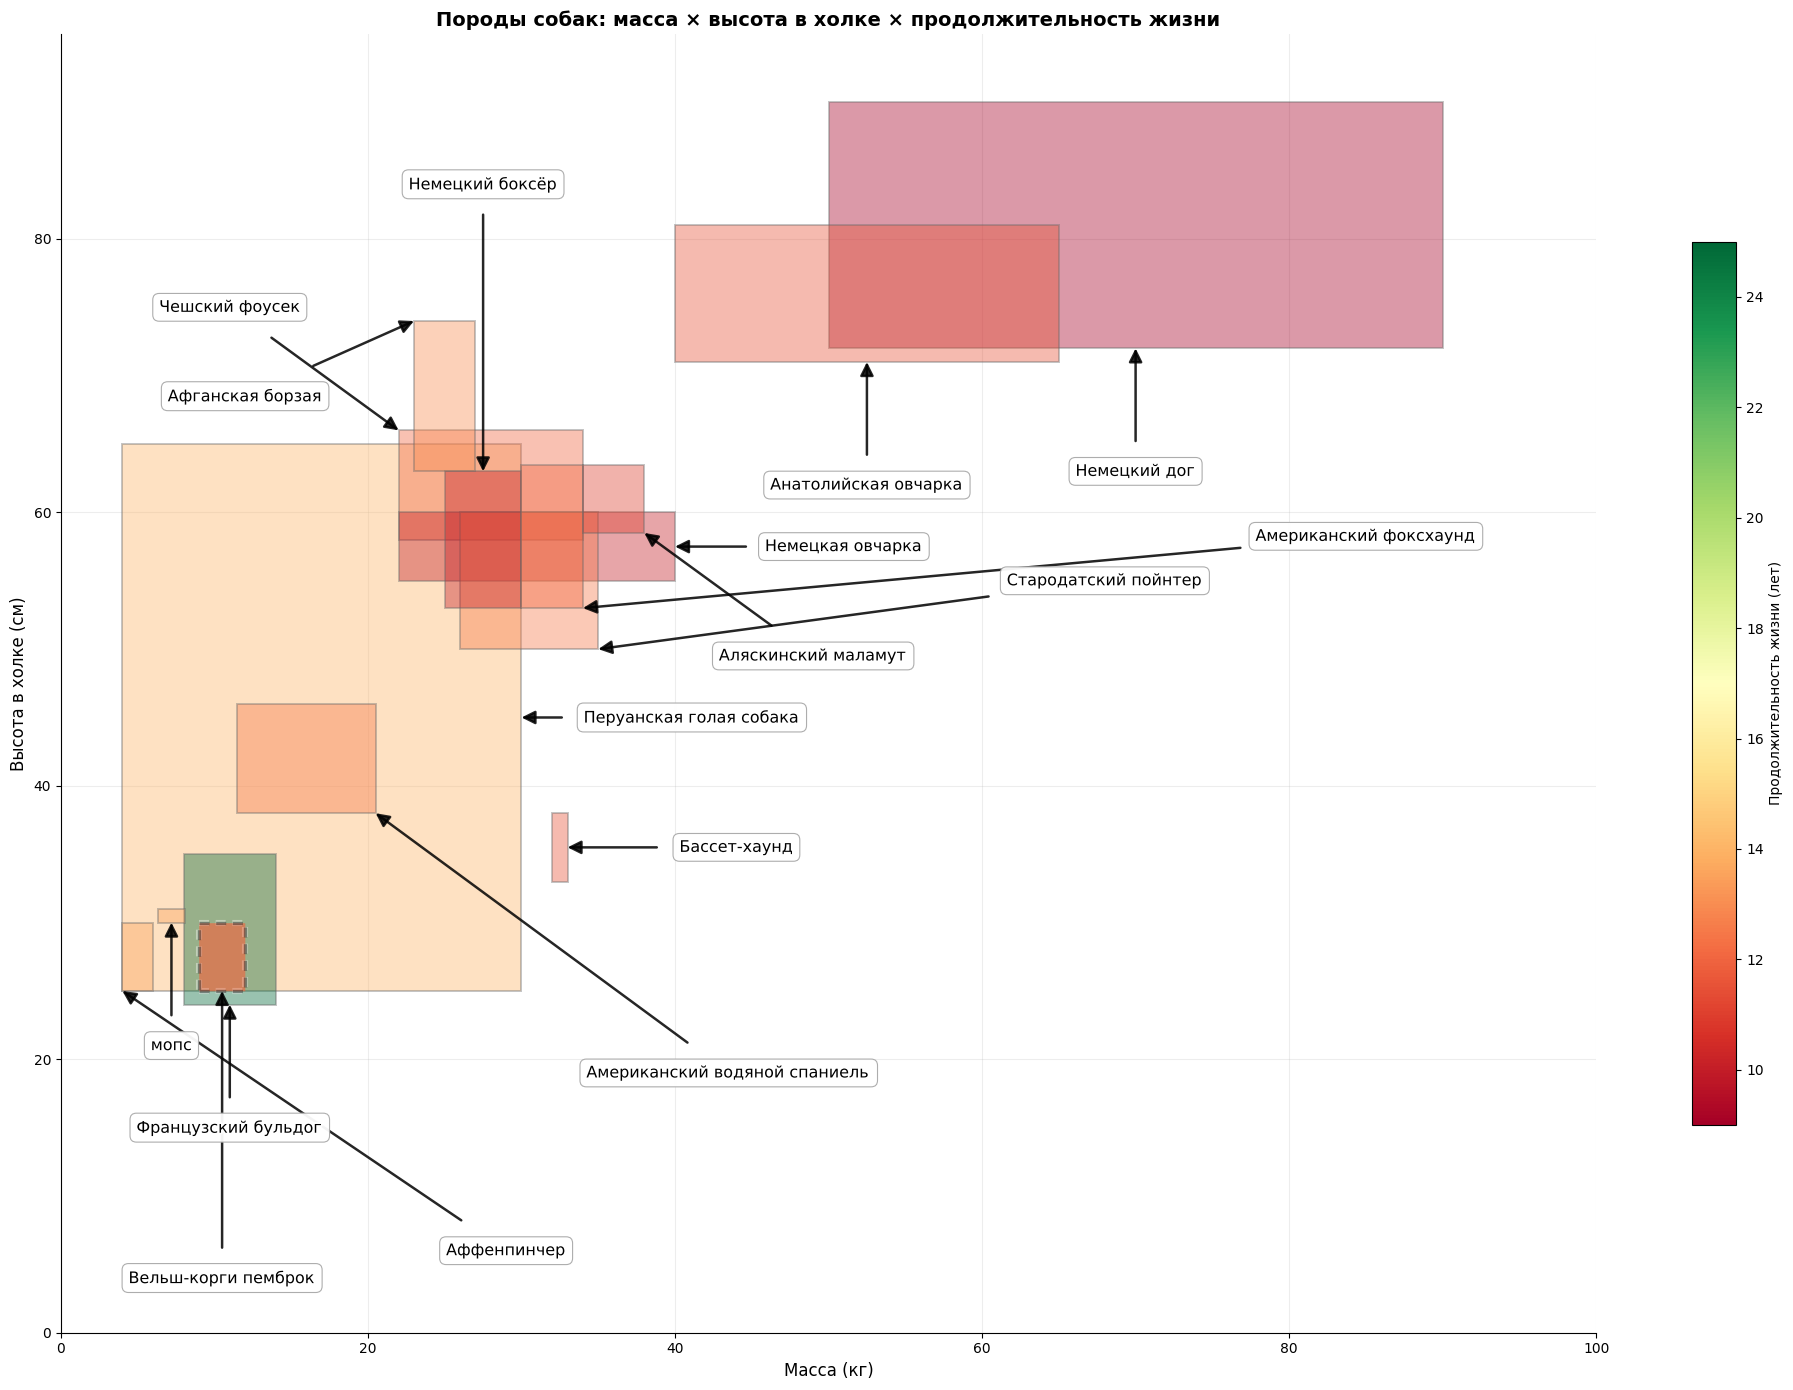

In [16]:
from matplotlib.patches import Rectangle, FancyArrowPatch
import matplotlib.patheffects as pe
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np

# ============================================================
# ПАРАМЕТРЫ — ФИНАЛЬНАЯ ОПТИМИЗАЦИЯ
# ============================================================
FIGSIZE = (20, 14)

X_MIN, X_MAX = 0, 100
Y_MIN, Y_MAX = 0, 95

LABEL_FONT_SIZE = 11.5
ARROW_LINEWIDTH = 1.8
ARROW_HEAD_SCALE = 20

RECT_ALPHA = 0.40
BASE_RECT_EDGEWIDTH = 1.4

LABEL_MARGIN_X = 1.6
LABEL_MARGIN_Y = 1.2
LABEL_OFFSET_X = 11.0
LABEL_OFFSET_Y = 9.0

PENALTY_OUTSIDE = 2_000_000
PENALTY_OVER_RECT = 60_000
PENALTY_OVER_OWN_RECT = 80_000
PENALTY_OVER_LABEL = 150_000
PENALTY_ARROW_CROSS_RECT = 20_000
PENALTY_ARROW_CROSS_ARROW = 25_000
PENALTY_NEAR_AXIS = 12_000

# Увеличен штраф за длину стрелки — чтобы подписи были ближе к своим прямоугольникам
ARROW_LENGTH_PENALTY = 4.0    # было 1.8

# Минимальное расстояние между подписями
MIN_LABEL_DISTANCE = 3.5      # чуть больше

# ============================================================
# ПОДГОТОВКА ДАННЫХ
# ============================================================
plot_df = df_combined.copy()

plot_df["plot_mass_w"] = (plot_df["mass_max"] - plot_df["mass_min"]).clip(lower=1.0)
plot_df["plot_height_h"] = (plot_df["height_max"] - plot_df["height_min"]).clip(lower=1.0)
plot_df["plot_x1"] = plot_df["mass_min"]
plot_df["plot_y1"] = plot_df["height_min"]
plot_df["plot_x2"] = plot_df["plot_x1"] + plot_df["plot_mass_w"]
plot_df["plot_y2"] = plot_df["plot_y1"] + plot_df["plot_height_h"]
plot_df["plot_area"] = plot_df["plot_mass_w"] * plot_df["plot_height_h"]

life_min = plot_df["lifeExpectancy"].min()
life_max = plot_df["lifeExpectancy"].max()
life_range = max(life_max - life_min, 1e-9)

norm = mcolors.Normalize(vmin=life_min, vmax=life_max)
cmap = cm.RdYlGn

# ============================================================
# ГЕОМЕТРИЯ
# ============================================================
def rect_tuple(row):
    return (row["plot_x1"], row["plot_y1"], row["plot_x2"], row["plot_y2"])

def rect_center(box):
    x1, y1, x2, y2 = box
    return ((x1 + x2) / 2, (y1 + y2) / 2)

def rect_area(box):
    x1, y1, x2, y2 = box
    return max(0, (x2 - x1)) * max(0, (y2 - y1))

def overlap_area(a, b):
    ax1, ay1, ax2, ay2 = a
    bx1, by1, bx2, by2 = b
    dx = max(0, min(ax2, bx2) - max(ax1, bx1))
    dy = max(0, min(ay2, by2) - max(ay1, by1))
    return dx * dy

def rects_overlap(a, b):
    return overlap_area(a, b) > 0

def contains_rect(outer, inner, eps=1e-9):
    ox1, oy1, ox2, oy2 = outer
    ix1, iy1, ix2, iy2 = inner
    return (ox1 - eps <= ix1 <= ox2 + eps and
            ox1 - eps <= ix2 <= ox2 + eps and
            oy1 - eps <= iy1 <= oy2 + eps and
            oy1 - eps <= iy2 <= oy2 + eps)

def point_in_rect(pt, box, eps=1e-9):
    x, y = pt
    x1, y1, x2, y2 = box
    return (x1 + eps < x < x2 - eps) and (y1 + eps < y < y2 - eps)

def ccw(a, b, c):
    return (c[1] - a[1]) * (b[0] - a[0]) > (b[1] - a[1]) * (c[0] - a[0])

def segments_intersect(p1, p2, q1, q2):
    def on_segment(a, b, c):
        return (min(a[0], c[0]) <= b[0] <= max(a[0], c[0]) and
                min(a[1], c[1]) <= b[1] <= max(a[1], c[1]))

    def orientation(a, b, c):
        val = (b[1] - a[1]) * (c[0] - b[0]) - (b[0] - a[0]) * (c[1] - b[1])
        if abs(val) < 1e-9:
            return 0
        return 1 if val > 0 else 2

    o1 = orientation(p1, p2, q1)
    o2 = orientation(p1, p2, q2)
    o3 = orientation(q1, q2, p1)
    o4 = orientation(q1, q2, p2)

    if o1 != o2 and o3 != o4:
        return True

    if o1 == 0 and on_segment(p1, q1, p2): return True
    if o2 == 0 and on_segment(p1, q2, p2): return True
    if o3 == 0 and on_segment(q1, p1, q2): return True
    if o4 == 0 and on_segment(q1, p2, q2): return True
    return False

def segment_intersects_rect(p1, p2, box):
    x1, y1, x2, y2 = box
    corners = [(x1, y1), (x2, y1), (x2, y2), (x1, y2)]
    edges = list(zip(corners, corners[1:] + [corners[0]]))

    if point_in_rect(p1, box) or point_in_rect(p2, box):
        return True

    for a, b in edges:
        if segments_intersect(p1, p2, a, b):
            return True
    return False

def box_distance(a, b):
    ca = rect_center(a)
    cb = rect_center(b)
    return np.hypot(ca[0] - cb[0], ca[1] - cb[1])

# ============================================================
# ФИГУРА И ПЕРЕВОД pt -> data units
# ============================================================
fig, ax = plt.subplots(figsize=FIGSIZE)
fig.canvas.draw()

ax_bbox_inches = ax.get_window_extent().transformed(fig.dpi_scale_trans.inverted())
x_units_per_pt = (X_MAX - X_MIN) / (ax_bbox_inches.width * 72)
y_units_per_pt = (Y_MAX - Y_MIN) / (ax_bbox_inches.height * 72)

def estimate_label_box(text, center_xy, fontsize=LABEL_FONT_SIZE):
    cx, cy = center_xy
    width = max(5.5, len(text) * fontsize * 0.58 * x_units_per_pt) + 2 * LABEL_MARGIN_X
    height = fontsize * 1.45 * y_units_per_pt + 2 * LABEL_MARGIN_Y
    return (cx - width / 2, cy - height / 2, cx + width / 2, cy + height / 2)

def label_edge_point(label_box, target_pt):
    x1, y1, x2, y2 = label_box
    cx, cy = (x1 + x2) / 2, (y1 + y2) / 2
    tx, ty = target_pt
    dx, dy = tx - cx, ty - cy

    half_w = max((x2 - x1) / 2, 1e-9)
    half_h = max((y2 - y1) / 2, 1e-9)

    scale = max(abs(dx) / half_w, abs(dy) / half_h, 1e-9)
    return (cx + dx / scale, cy + dy / scale)

# ============================================================
# КАНДИДАТЫ ДЛЯ ПОДПИСЕЙ — С ГОРИЗОНТАЛЬНЫМИ ПОЗИЦИЯМИ СПРАВА
# ============================================================
def label_candidates(box):
    x1, y1, x2, y2 = box
    cx, cy = rect_center(box)

    dx = max(LABEL_OFFSET_X, 0.35 * (x2 - x1) + 2.0)
    dy = max(LABEL_OFFSET_Y, 0.35 * (y2 - y1) + 2.0)

    return {
        # Базовые 8 направлений
        "N"  : (cx,      y2 + dy),
        "NE" : (x2 + dx, y2 + dy),
        "E"  : (x2 + dx, cy),
        "SE" : (x2 + dx, y1 - dy),
        "S"  : (cx,      y1 - dy),
        "SW" : (x1 - dx, y1 - dy),
        "W"  : (x1 - dx, cy),
        "NW" : (x1 - dx, y2 + dy),

        # Дальние позиции
        "N2" : (cx,      y2 + dy + 12),
        "NE2": (x2 + dx + 12, y2 + dy + 10),
        "E2" : (x2 + dx + 14, cy),
        "SE2": (x2 + dx + 12, y1 - dy - 10),
        "S2" : (cx,      y1 - dy - 12),
        "SW2": (x1 - dx - 12, y1 - dy - 10),
        "W2" : (x1 - dx - 14, cy),
        "NW2": (x1 - dx - 12, y2 + dy + 10),

        # Очень дальние
        "N3" : (cx,      y2 + dy + 20),
        "NE3": (x2 + dx + 20, y2 + dy + 16),
        "E3" : (x2 + dx + 22, cy),
        "SE3": (x2 + dx + 20, y1 - dy - 16),
        "S3" : (cx,      y1 - dy - 20),
        "SW3": (x1 - dx - 20, y1 - dy - 16),
        "W3" : (x1 - dx - 22, cy),
        "NW3": (x1 - dx - 20, y2 + dy + 16),

        # Горизонтальные дальние (специально для правой части графика)
        "E_FAR" : (x2 + dx + 30, cy),
        "NE_FAR": (x2 + dx + 25, y2 + dy + 20),
        "SE_FAR": (x2 + dx + 25, y1 - dy - 20),
        "E_VFAR": (x2 + dx + 40, cy),
    }

# ============================================================
# КАНДИДАТЫ ДЛЯ ТОЧКИ ПРИХОДА СТРЕЛКИ
# ============================================================
boxes_by_name = {
    row["dogBreed_ru"]: rect_tuple(row)
    for _, row in plot_df.iterrows()
}

def visible_anchor_candidates(name, own_box, all_boxes):
    x1, y1, x2, y2 = own_box
    cx, cy = rect_center(own_box)

    candidates = [
        (cx, y2),   # top
        (x2, cy),   # right
        (cx, y1),   # bottom
        (x1, cy),   # left
        (x1, y2),   # tl
        (x2, y2),   # tr
        (x2, y1),   # br
        (x1, y1),   # bl
    ]

    for other_name, other_box in all_boxes.items():
        if other_name == name:
            continue
        if contains_rect(own_box, other_box) and rect_area(other_box) < rect_area(own_box):
            ox1, oy1, ox2, oy2 = other_box
            strip_candidates = [
                (ox1 - x1, (x1 + (ox1 - x1) / 2, cy)),
                (x2 - ox2, (ox2 + (x2 - ox2) / 2, cy)),
                (oy1 - y1, (cx, y1 + (oy1 - y1) / 2)),
                (y2 - oy2, (cx, oy2 + (y2 - oy2) / 2)),
            ]
            for width, pt in strip_candidates:
                if width > 0.6:
                    candidates.append(pt)

    unique = []
    for pt in candidates:
        rounded = (round(pt[0], 3), round(pt[1], 3))
        if rounded not in unique:
            unique.append(rounded)

    final_pts = []
    for pt in unique:
        ok = True
        for other_name, other_box in all_boxes.items():
            if other_name == name:
                continue
            if contains_rect(own_box, other_box) and rect_area(other_box) < rect_area(own_box):
                if point_in_rect(pt, other_box):
                    ok = False
                    break
        if ok:
            final_pts.append(pt)

    return final_pts

# ============================================================
# ПОРЯДОК РАЗМЕЩЕНИЯ
# ============================================================
overlap_count = []
all_names = list(boxes_by_name.keys())

for name in all_names:
    box = boxes_by_name[name]
    count = 0
    for other_name in all_names:
        if other_name == name:
            continue
        other_box = boxes_by_name[other_name]
        if rects_overlap(box, other_box) or contains_rect(box, other_box) or contains_rect(other_box, box):
            count += 1
    overlap_count.append((name, count, rect_area(box)))

placement_order = [
    name for name, _, _ in
    sorted(overlap_count, key=lambda t: (-t[1], -t[2], t[0]))
]

# ============================================================
# СПЕЦИАЛЬНОЕ РАЗЛИЧЕНИЕ ДЛЯ ВЛОЖЕННОЙ ПАРЫ
# ============================================================
special_pair = ["Французский бульдог", "Вельш-корги пемброк"]
special_small = None
if all(name in boxes_by_name for name in special_pair):
    area_a = rect_area(boxes_by_name[special_pair[0]])
    area_b = rect_area(boxes_by_name[special_pair[1]])
    special_small = special_pair[0] if area_a < area_b else special_pair[1]

# ============================================================
# РИСУЕМ ПРЯМОУГОЛЬНИКИ
# ============================================================
patches = {}
for _, row in plot_df.sort_values("plot_area", ascending=False).iterrows():
    name = row["dogBreed_ru"]
    box = rect_tuple(row)
    x1, y1, x2, y2 = box
    color = cmap(norm(row["lifeExpectancy"]))

    edgecolor = "dimgray"
    linewidth = BASE_RECT_EDGEWIDTH
    linestyle = "-"
    z = 2 + (1000 - row["plot_area"]) * 1e-4

    if name == special_small:
        edgecolor = "black"
        linewidth = 2.4
        linestyle = (0, (3, 2))
        z = 6

    patch = Rectangle(
        (x1, y1),
        x2 - x1,
        y2 - y1,
        facecolor=color,
        edgecolor=edgecolor,
        linewidth=linewidth,
        linestyle=linestyle,
        alpha=RECT_ALPHA,
        zorder=z,
    )

    if name == special_small:
        patch.set_path_effects([
            pe.Stroke(linewidth=linewidth + 2.0, foreground="white"),
            pe.Normal()
        ])

    ax.add_patch(patch)
    patches[name] = patch

# ============================================================
# ПОИСК ЛУЧШИХ ПОЗИЦИЙ ПОДПИСЕЙ И СТРЕЛОК
# ============================================================
placed_label_boxes = {}
placed_arrow_segments = {}
final_layout = {}

def candidate_cost(name, label_center, anchor_pt, own_box):
    text = name
    label_box = estimate_label_box(text, label_center, fontsize=LABEL_FONT_SIZE)
    arrow_start = label_edge_point(label_box, anchor_pt)

    cost = 0.0

    lx1, ly1, lx2, ly2 = label_box
    if lx1 < X_MIN + 0.4 or lx2 > X_MAX - 0.4 or ly1 < Y_MIN + 0.4 or ly2 > Y_MAX - 0.4:
        cost += PENALTY_OUTSIDE
    if lx1 < X_MIN + 1.2 or ly1 < Y_MIN + 1.2:
        cost += PENALTY_NEAR_AXIS

    for other_name, other_box in boxes_by_name.items():
        inter = overlap_area(label_box, other_box)
        if inter > 0:
            if other_name == name:
                cost += PENALTY_OVER_OWN_RECT + 40 * inter
            else:
                cost += PENALTY_OVER_RECT + 35 * inter

    for other_name, other_label_box in placed_label_boxes.items():
        inter = overlap_area(label_box, other_label_box)
        if inter > 0:
            cost += PENALTY_OVER_LABEL + 60 * inter
        dist = box_distance(label_box, other_label_box)
        if dist < MIN_LABEL_DISTANCE:
            cost += (MIN_LABEL_DISTANCE - dist) * 8000

    for other_name, other_box in boxes_by_name.items():
        if other_name == name:
            continue
        if segment_intersects_rect(arrow_start, anchor_pt, other_box):
            cost += PENALTY_ARROW_CROSS_RECT

    for other_name, (p1, p2) in placed_arrow_segments.items():
        if segments_intersect(arrow_start, anchor_pt, p1, p2):
            cost += PENALTY_ARROW_CROSS_ARROW

    # Увеличен штраф за длину стрелки
    arrow_len = np.hypot(anchor_pt[0] - arrow_start[0], anchor_pt[1] - arrow_start[1])
    cost += ARROW_LENGTH_PENALTY * arrow_len

    # Небольшой бонус за размещение сверху (визуально приятнее)
    cx, cy = rect_center(own_box)
    if label_center[1] >= cy:
        cost -= 3.0

    return cost, label_box, arrow_start

for name in placement_order:
    own_box = boxes_by_name[name]

    best = None
    best_payload = None

    for label_center in label_candidates(own_box).values():
        for anchor_pt in visible_anchor_candidates(name, own_box, boxes_by_name):
            cost, label_box, arrow_start = candidate_cost(name, label_center, anchor_pt, own_box)
            if best is None or cost < best:
                best = cost
                best_payload = {
                    "label_center": label_center,
                    "label_box": label_box,
                    "arrow_start": arrow_start,
                    "anchor_pt": anchor_pt,
                }

    placed_label_boxes[name] = best_payload["label_box"]
    placed_arrow_segments[name] = (best_payload["arrow_start"], best_payload["anchor_pt"])
    final_layout[name] = best_payload

# ============================================================
# РИСУЕМ СТРЕЛКИ И ПОДПИСИ
# ============================================================
for name in placement_order:
    layout = final_layout[name]
    start = layout["arrow_start"]
    end = layout["anchor_pt"]
    text_x, text_y = layout["label_center"]

    arrow = FancyArrowPatch(
        start, end,
        arrowstyle="-|>",
        mutation_scale=ARROW_HEAD_SCALE,
        linewidth=ARROW_LINEWIDTH,
        color="black",
        alpha=0.85,
        zorder=8,
        shrinkA=0,
        shrinkB=0,
        connectionstyle="arc3,rad=0.0"
    )
    ax.add_patch(arrow)

    txt = ax.text(
        text_x, text_y, name,
        fontsize=LABEL_FONT_SIZE,
        ha="center", va="center",
        zorder=9,
        bbox=dict(
            boxstyle="round,pad=0.4",
            facecolor="white",
            edgecolor="darkgray",
            linewidth=0.8,
            alpha=0.95
        )
    )
    txt.set_path_effects([
        pe.Stroke(linewidth=2.5, foreground="white"),
        pe.Normal()
    ])

# ============================================================
# ОФОРМЛЕНИЕ
# ============================================================
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, label="Продолжительность жизни (лет)", shrink=0.68)

ax.set_xlabel("Масса (кг)", fontsize=12)
ax.set_ylabel("Высота в холке (см)", fontsize=12)
ax.set_title(
    "Породы собак: масса × высота в холке × продолжительность жизни",
    fontsize=14,
    fontweight="bold"
)

ax.set_xlim(X_MIN, X_MAX)
ax.set_ylim(Y_MIN, Y_MAX)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.tick_params(top=False, right=False)

ax.grid(True, alpha=0.22, zorder=0)

plt.tight_layout()
plt.show()